<a href="https://colab.research.google.com/github/arielmadr/Differential-Gene-Expression-Analysis/blob/main/Exercises/scripts/Differential_Gene_Expression_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Differential Gene Expression Analysis


## Install dependencies

This session will guide you to use DESeq2 to identify differentially expressed genes and become familiar with design matrices. The session will also introduce concepts essential for working with real-world data, such as incorporating covariates and interaction terms into models.

The objectives of this session are:

* Obtain familiarity with the DESeq2 workflow
* Design and configure differential expression models appropriately for RNA-seq data



In [ ]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")


In [ ]:
BiocManager::install(c("DESeq2", "vsn", "EnhancedVolcano", "fgsea"))
install.packages(c("hexbin", "pheatmap", "RColorBrewer", "ggplot2", "ggbeeswarm", "ashr", "knit", "GSA", "enrichR"))


'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'vsn' 'EnhancedVolcano' 'fgsea'”
Old packages: 'gh', 'xfun', 'xtable'

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘knit’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


## Dataset

This workshop will use processed RNA-seq counts from this [study](https://doi.org/10.1016/j.stem.2021.04.028), where they studied the transcriptional response to SARS-CoV-2 infection in three tissues (cornea, limbus, sclera). The dataset consists of 18 samples, with three replicates per tissue and condition (mock vs CoV-2).


## 01 Run DESeq2

### Load libraries


In [ ]:
library(DESeq2)
library(vsn) # Used for standard deviation vs mean plots
library(hexbin) # Used for standard deviation vs mean plots
library(pheatmap)
library(RColorBrewer)
library(EnhancedVolcano)
library(ggplot2)
library(ggbeeswarm)
library(ashr) # Used for log-fold shrinkage
library(knitr) # Used for formatting output
library(fgsea)
library(GSA)
library(RColorBrewer)
library(enrichR)
set.seed(43)

Set plotting size configurations

In [ ]:
options(repr.plot.width = 9, repr.plot.height = 7)
theme_set(theme_gray(base_size = 20))

### Load the data

In [ ]:
dir_project="https://raw.githubusercontent.com/QLS-MiCM/Differential-Gene-Expression-Analysis/refs/heads/main/Exercises/"
raw_counts<- read.table(paste0(dir_project, "data/GSE164073_Eye_count_matrix.tsv"), header=T, row.names=1)
meta<- read.table(paste0(dir_project,"data/GSE164073_Eye_count_meta.tsv"), row.names=1)
kable(head(raw_counts[,1:5]))
kable(head(meta))



|         | MW1| MW2| MW3| MW4| MW5|
|:--------|---:|---:|---:|---:|---:|
|A1BG     |  91| 131|  86|  77|  69|
|A1BG-AS1 | 292| 284| 271| 232| 250|
|A1CF     |   0|   0|   0|   0|   0|
|A2M      | 255| 273| 263| 150| 176|
|A2M-AS1  |   8|   9|   9|  11|  16|
|A2ML1    |   0|   0|   0|   0|   0|



|    |Tissue |Condition |
|:---|:------|:---------|
|MW1 |cornea |mock      |
|MW2 |cornea |mock      |
|MW3 |cornea |mock      |
|MW4 |cornea |CoV2      |
|MW5 |cornea |CoV2      |
|MW6 |cornea |CoV2      |

### Create DESeq2 object

The first step is to create a design matrix. Let's start by creating a very simple design matrix.

In [ ]:
# Converting Tissue into a factor
meta$Tissue<- factor(meta$Tissue)
# Adjusting levels for Condition, so that mock is the reference
meta$Condition<- factor(meta$Condition, levels=c("mock", "CoV2"))
meta_design<- model.matrix( ~ Condition, data=meta)
kable(head(meta_design))



|    | (Intercept)| ConditionCoV2|
|:---|-----------:|-------------:|
|MW1 |           1|             0|
|MW2 |           1|             0|
|MW3 |           1|             0|
|MW4 |           1|             1|
|MW5 |           1|             1|
|MW6 |           1|             1|

This design matrix is answering the **question**: What are the overall differences between Mock and CoV2, without considering the tissues?

Now, let's create a DESeq2 object.



In [ ]:
dds <- DESeqDataSetFromMatrix(countData = raw_counts,
                              colData = meta,
                              design= meta_design)

In [ ]:
dds

class: DESeqDataSet 
dim: 27946 18 
metadata(1): version
assays(1): counts
rownames(27946): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(0):
colnames(18): MW1 MW2 ... MW17 MW18
colData names(2): Tissue Condition

### Prefiltering

Removing low expressed counts is generally recommended for memory and speed reasons.

In [ ]:
smallestGroupSize <- 3
keep <- rowSums(counts(dds) >= 10) >= smallestGroupSize
dds <- dds[keep,]
dds

class: DESeqDataSet 
dim: 14700 18 
metadata(1): version
assays(1): counts
rownames(14700): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(0):
colnames(18): MW1 MW2 ... MW17 MW18
colData names(2): Tissue Condition

### Quality control

#### VST

We can obtain a variance stabilizing transformation

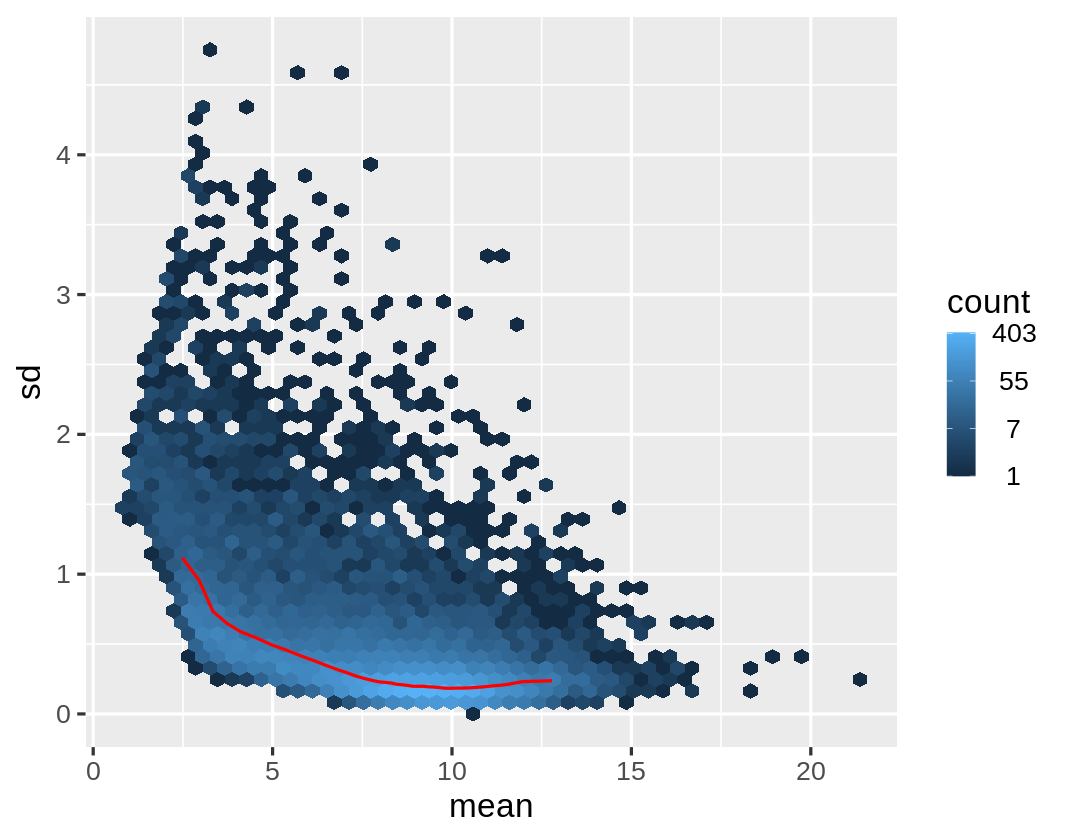

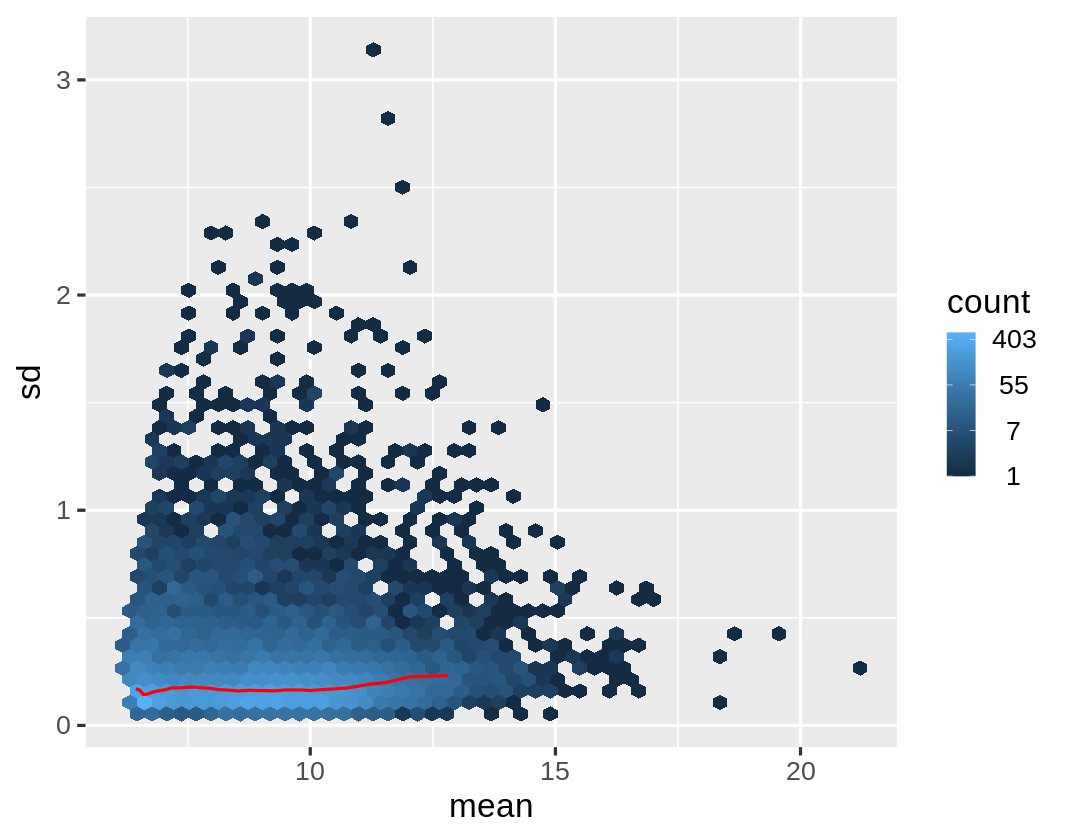

In [ ]:
# Obtain the variance stabilizing transformation
vsd <- vst(dds)
# Let's compare it to the normal transformation
ntd <- normTransform(dds)
meanSdPlot(assay(ntd), ranks=F) # Normal
meanSdPlot(assay(vsd), ranks=F) # VST

We observe that the vst removes the dependence of the variance on the mean, which is evident for the low expressed genes.

#### Heatmap of the sample-to-sample distances

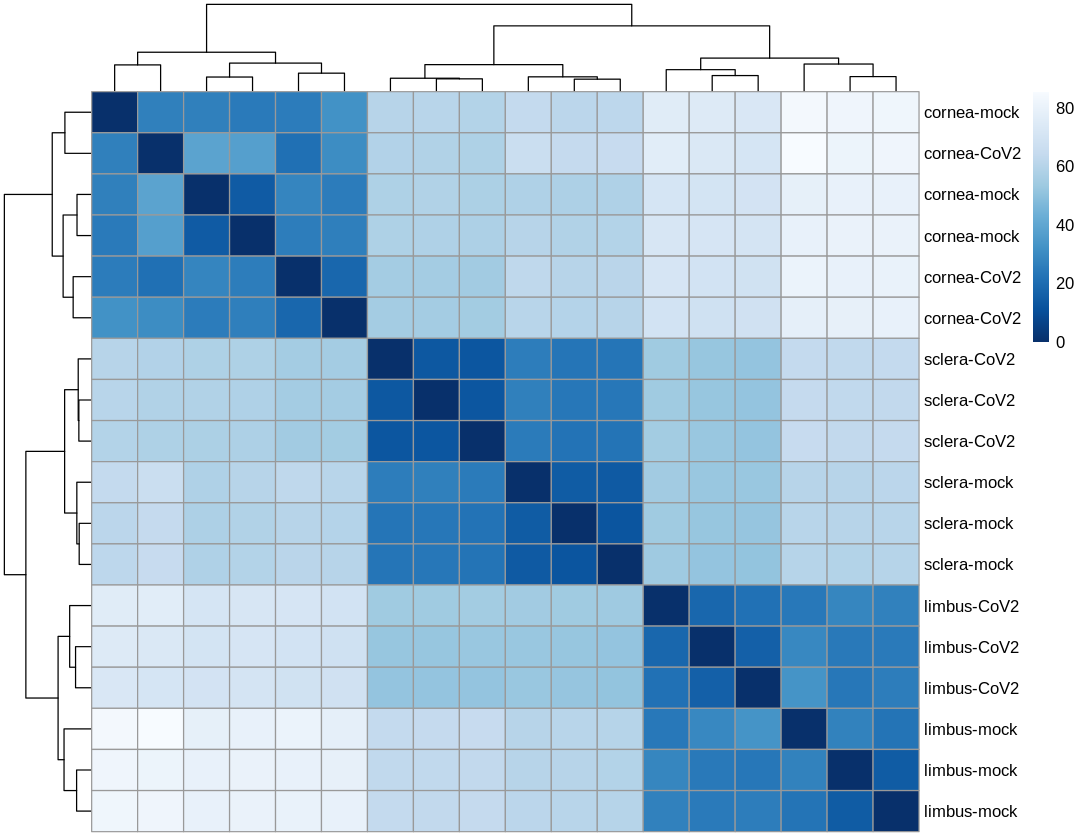

In [ ]:
sampleDists <- dist(t(assay(vsd)))
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vsd$Tissue, vsd$Condition, sep="-")
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

We observe that in general, samples from the same tissue cluster together, as expected.

#### Principal component of the samples

We can also perform a PCA analysis of the VST counts.

using ntop=500 top features by variance



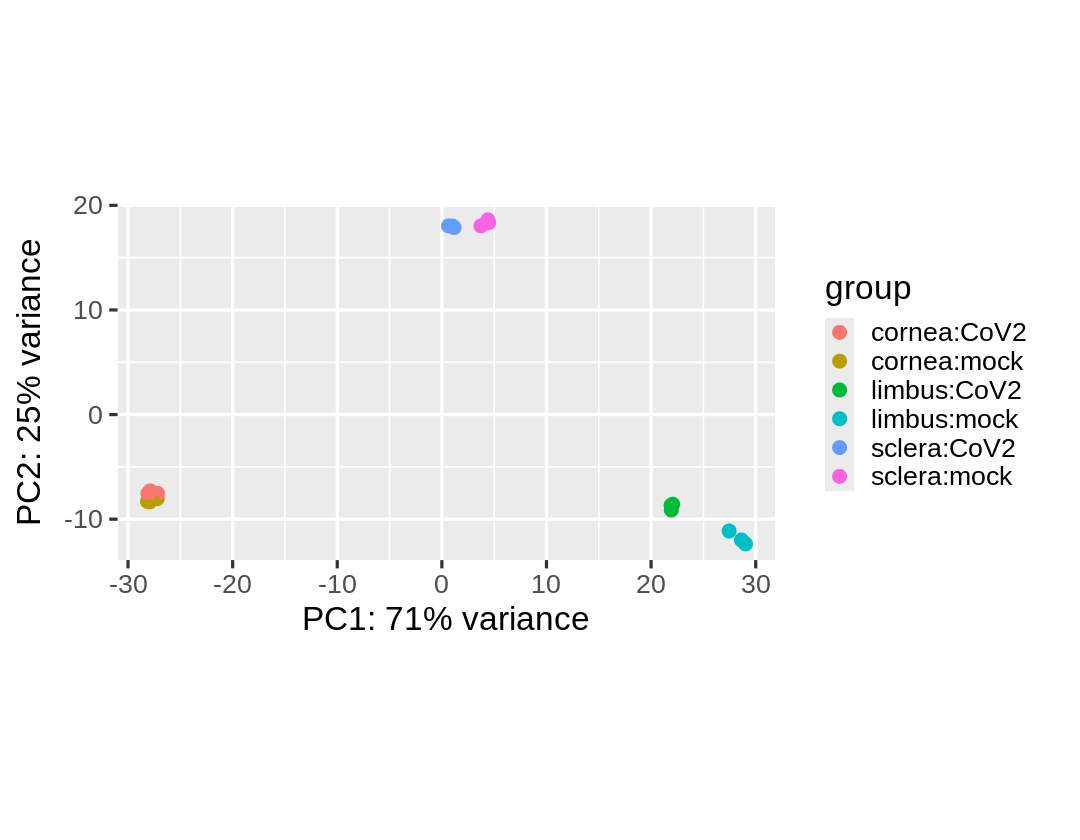

In [ ]:
plotPCA(vsd, intgroup=c("Tissue", "Condition")) +
    geom_point(size=0.25)

Again, we observe that the first PCA is mostly associated with tissue, although samples can also subcluster between the mock and CoV2 conditions.

### Differential expression

The standard DE is performed by the DESeq function.

In [ ]:
dds <- DESeq(dds)
dds

using supplied model matrix

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



class: DESeqDataSet 
dim: 14700 18 
metadata(1): version
assays(5): counts mu H cooks originalCounts
rownames(14700): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(23): baseMean baseVar ... maxCooks replace
colnames(18): MW1 MW2 ... MW17 MW18
colData names(4): Tissue Condition sizeFactor replaceable

In [ ]:
resultsNames(dds)
res <- results(dds, name="ConditionCoV2") # This function provides the lof2Fold Changes and p-values for a given coefficient name
res

[1] "Intercept"     "ConditionCoV2"

log2 fold change (MLE): ConditionCoV2 
Wald test p-value: ConditionCoV2 
DataFrame with 14700 rows and 6 columns
          baseMean log2FoldChange     lfcSE      stat    pvalue      padj
         <numeric>      <numeric> <numeric> <numeric> <numeric> <numeric>
A1BG       90.4475     -0.1439495  0.118021 -1.219695  0.222581  0.803126
A1BG-AS1  278.3007     -0.0480946  0.112076 -0.429126  0.667832  0.963881
A2M       873.3212     -0.8092580  0.741401 -1.091525  0.275042  0.833286
A2M-AS1    11.3404      0.4892287  0.256631  1.906348  0.056605  0.531853
A4GALT    775.8491      0.1133252  0.223626  0.506761  0.612322  0.951852
...            ...            ...       ...       ...       ...       ...
ZYG11A     17.6651     -0.3825263 0.3813743 -1.003021  0.315851  0.855794
ZYG11B   1385.1616      0.0993295 0.1068925  0.929246  0.352761  0.874910
ZYX      6722.2007     -0.2497730 0.1098916 -2.272903  0.023032  0.359851
ZZEF1    1364.0281      0.1296682 0.0923057  1.404769  0.160090  0.741104

Then, a results table can be generated. In this case, we provide a value in the 'name' argument in the results function, which correspondds to the CoV2 effect encoded in our design matrix. We will also explore other ways to access results in the follow up sections.

### Log Fold shrinkage

Shrinkage of the log-fold changes estimates is recommended for visualization and ranking of genes.

In [ ]:
resLFC <- lfcShrink(dds, coef="ConditionCoV2", type="ashr")

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



The lfcShrink has various shrinkage methods, here we will use ashr. Again, we look for the CoV2 effect model by setting up the coef argument in the lfcShrink function.

#### MA plots

Let's compare the MA plots between the shrunken FC and the regular FC.

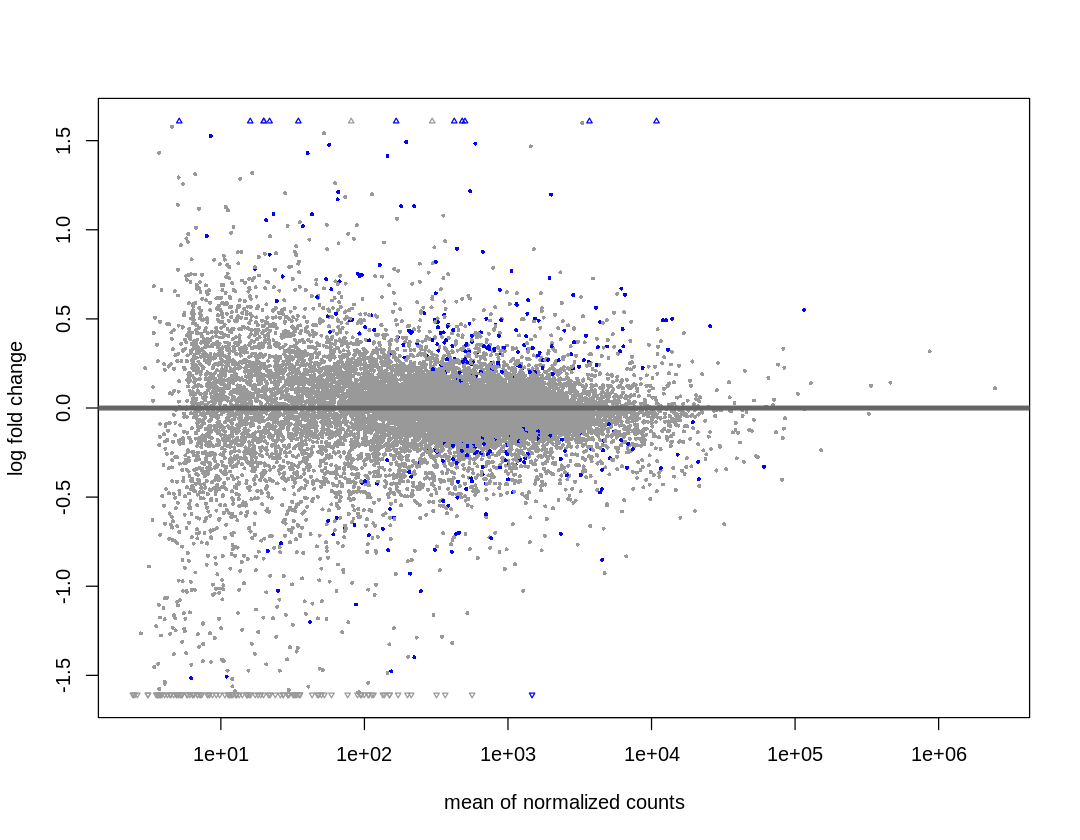

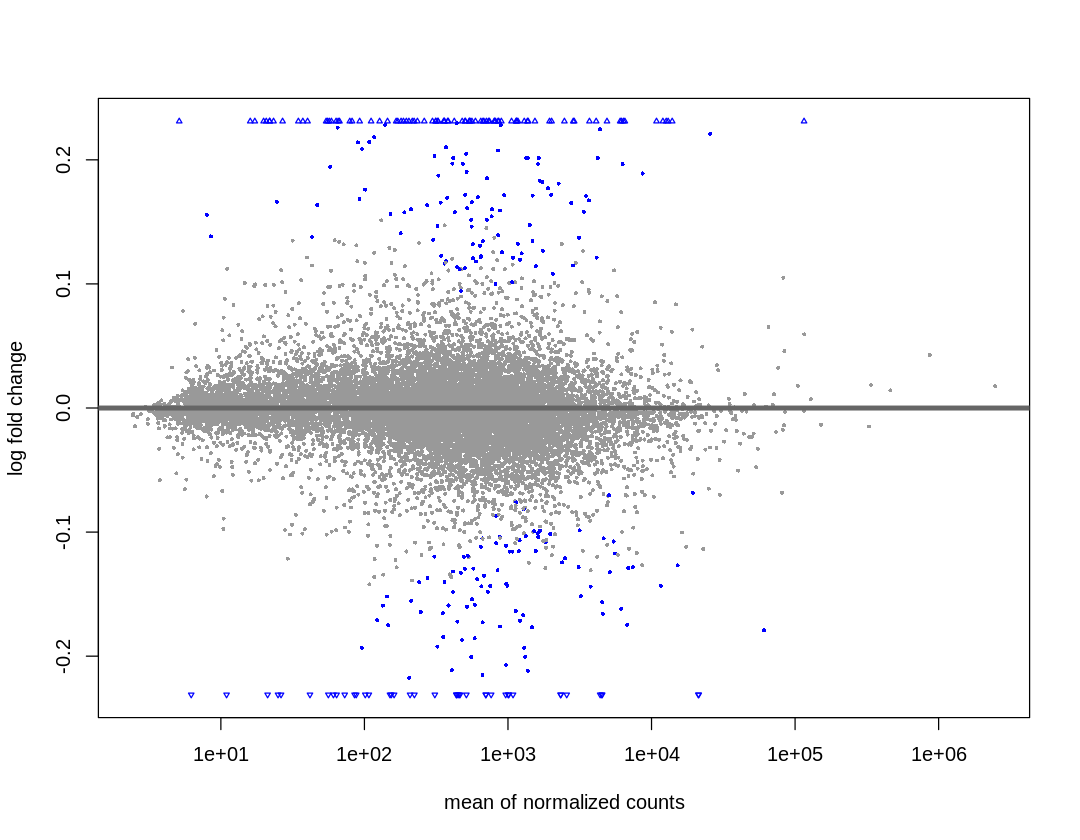

In [ ]:
plotMA(res)
plotMA(resLFC)

You can see that the shrunken log2 fold changes remove the noise associated with log2 fold changes from low count genes.

#### Volcano plot

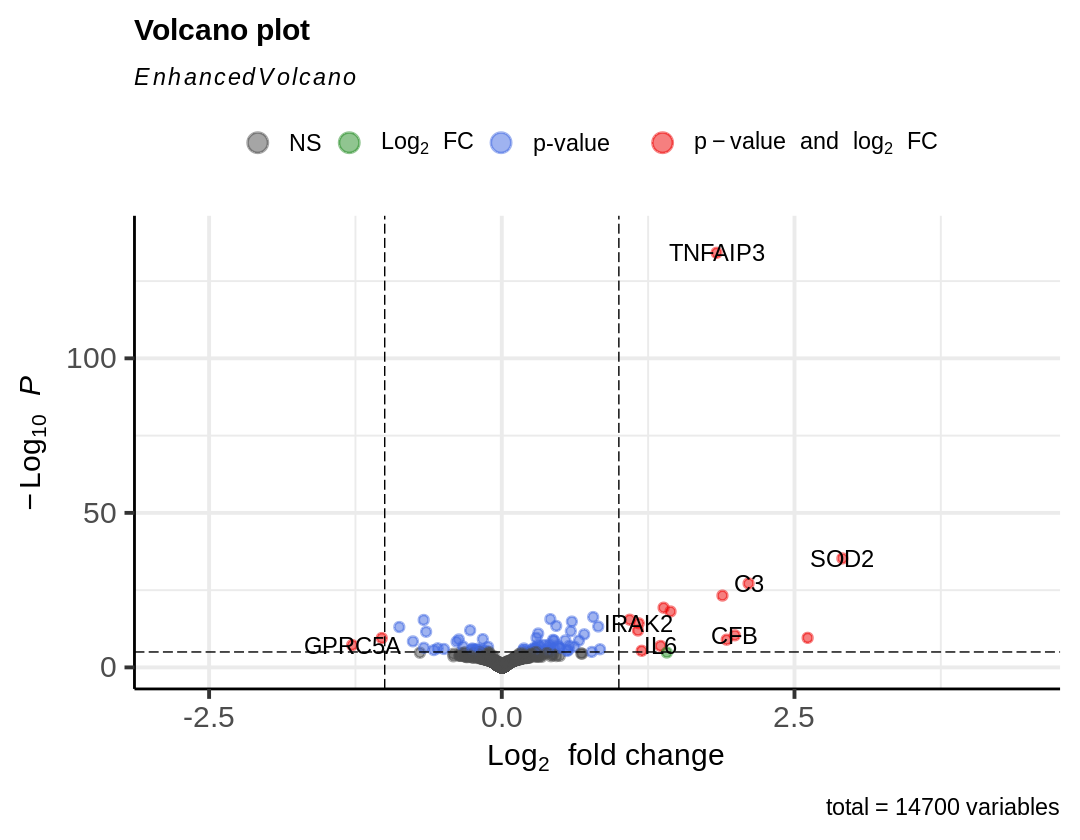

In [ ]:
EnhancedVolcano(resLFC,
                lab = rownames(resLFC),
                x = 'log2FoldChange',
                y = 'pvalue')

We can explore also the results using a Volcano Plot.

#### Plot counts

We can also plot the normalized count values for a given gene.


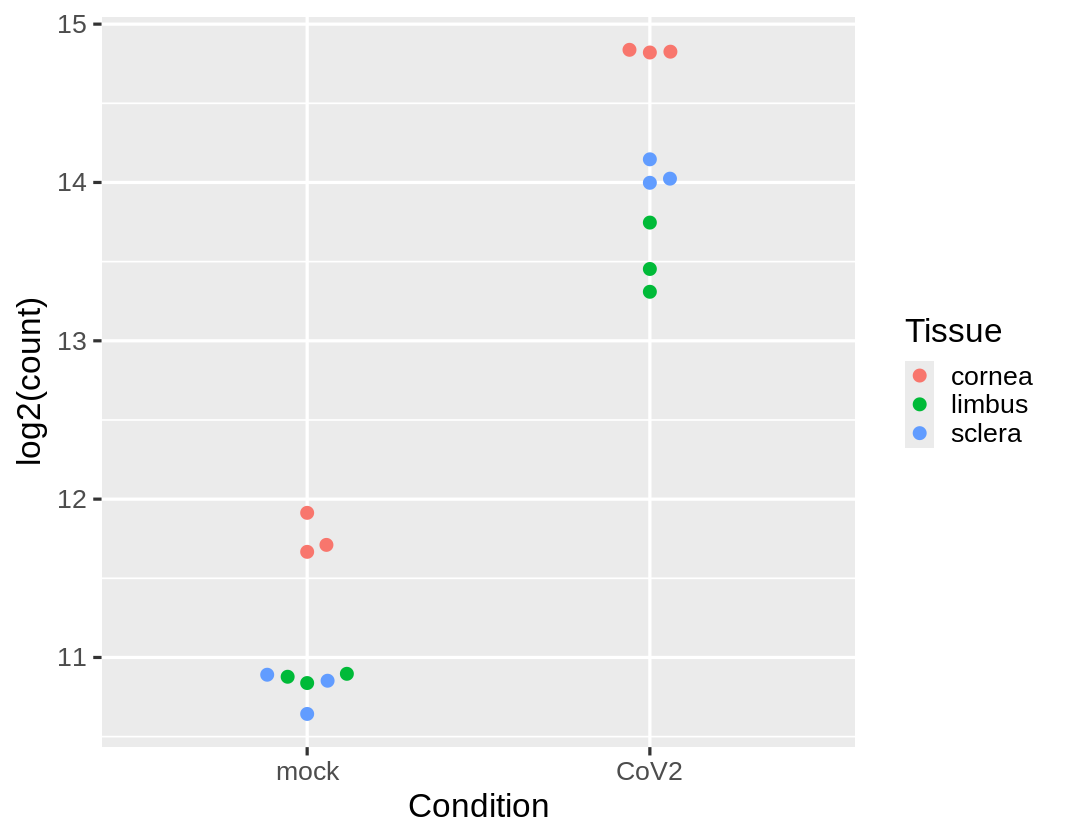

In [ ]:
geneCounts <- plotCounts(dds, gene = "SOD2", intgroup = c("Condition","Tissue"),returnData = T)
ggplot(geneCounts, aes(x = Condition, y = log2(count), color = Tissue)) +  geom_beeswarm(cex = 3)

#### Heatmaps

Finally, we can generate a heatmap for a subset of genes with significant DE changes (padj < 0.05 and log2FoldChange >1).

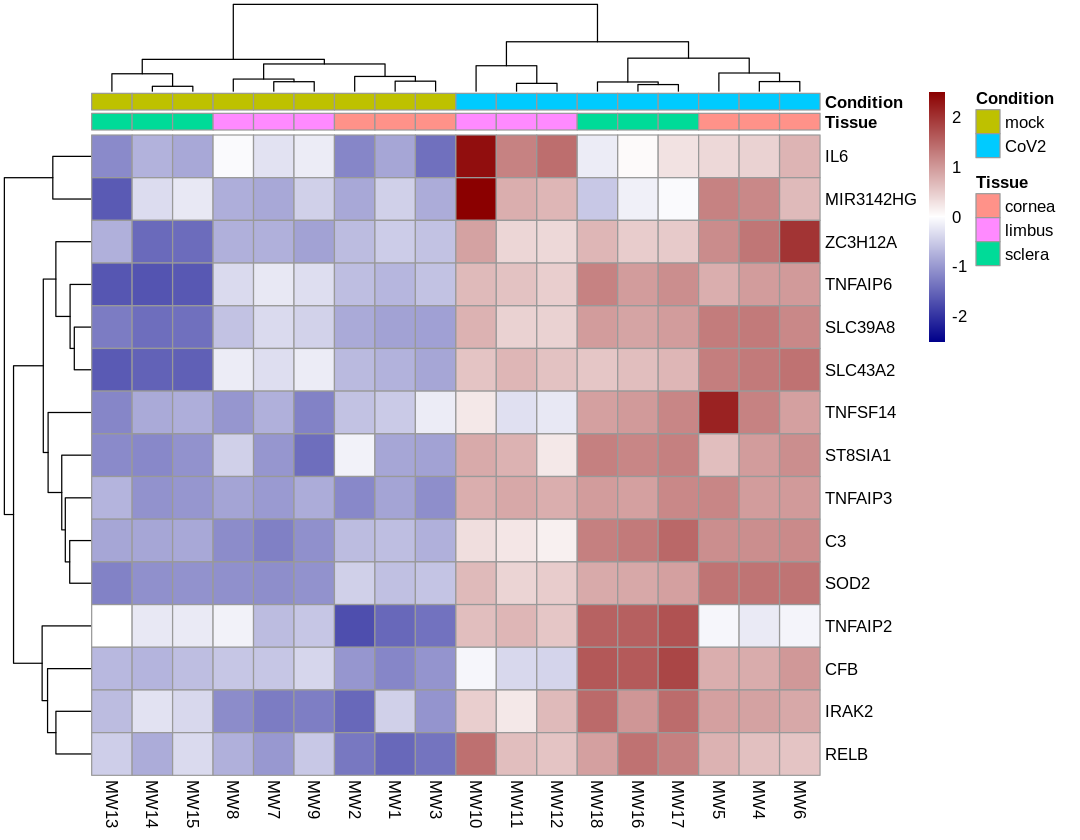

In [ ]:
sig_genes<- rownames(resLFC[with(resLFC, abs(log2FoldChange > 1) & padj < 0.05),])
colors <- colorRampPalette(c("darkblue","white","darkred"))(255)
pheatmap(assay(vsd[sig_genes,]), annotation_col=meta,col=colors, scale="row")

### Tissue specific effects

So far, we haven't considered the different tissues into our model. One way to study the tissue-specific effects is through a mean group model.

In [ ]:
meta$group<- factor(paste0(".", meta$Tissue, "_", meta$Condition))
meta_design<- model.matrix( ~ 0 + group, data=meta) # We remove the intercept in this model
kable(head(meta_design))



|    | group.cornea_CoV2| group.cornea_mock| group.limbus_CoV2| group.limbus_mock| group.sclera_CoV2| group.sclera_mock|
|:---|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|-----------------:|
|MW1 |                 0|                 1|                 0|                 0|                 0|                 0|
|MW2 |                 0|                 1|                 0|                 0|                 0|                 0|
|MW3 |                 0|                 1|                 0|                 0|                 0|                 0|
|MW4 |                 1|                 0|                 0|                 0|                 0|                 0|
|MW5 |                 1|                 0|                 0|                 0|                 0|                 0|
|MW6 |                 1|                 0|                 0|                 0|                 0|                 0|

This design is asking the **question**: What is the mean expression level in each tissue-condition group?
Then, via contrasts we can specify comparisons, like, what is the difference in expression between CoV2 and mock in Cornea

In [ ]:
design(dds)<- meta_design
dds <- DESeq(dds)
dds
resultsNames(dds)

using supplied model matrix

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



class: DESeqDataSet 
dim: 14700 18 
metadata(1): version
assays(5): counts mu H cooks originalCounts
rownames(14700): A1BG A1BG-AS1 ... ZZEF1 ZZZ3
rowData names(38): baseMean baseVar ... deviance maxCooks
colnames(18): MW1 MW2 ... MW17 MW18
colData names(4): Tissue Condition sizeFactor replaceable

[1] "group.cornea_CoV2" "group.cornea_mock" "group.limbus_CoV2"
[4] "group.limbus_mock" "group.sclera_CoV2" "group.sclera_mock"

We need to specify the contrast, asking what is the difference between CoV2 and mock in cornea. There are multiple ways to establish a contrast, one of them is to supply the contrast argument a list of two character vectors, a list of 2 character vectors: the names of the fold changes for the numerator, and the names of the fold changes for the denominator.

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



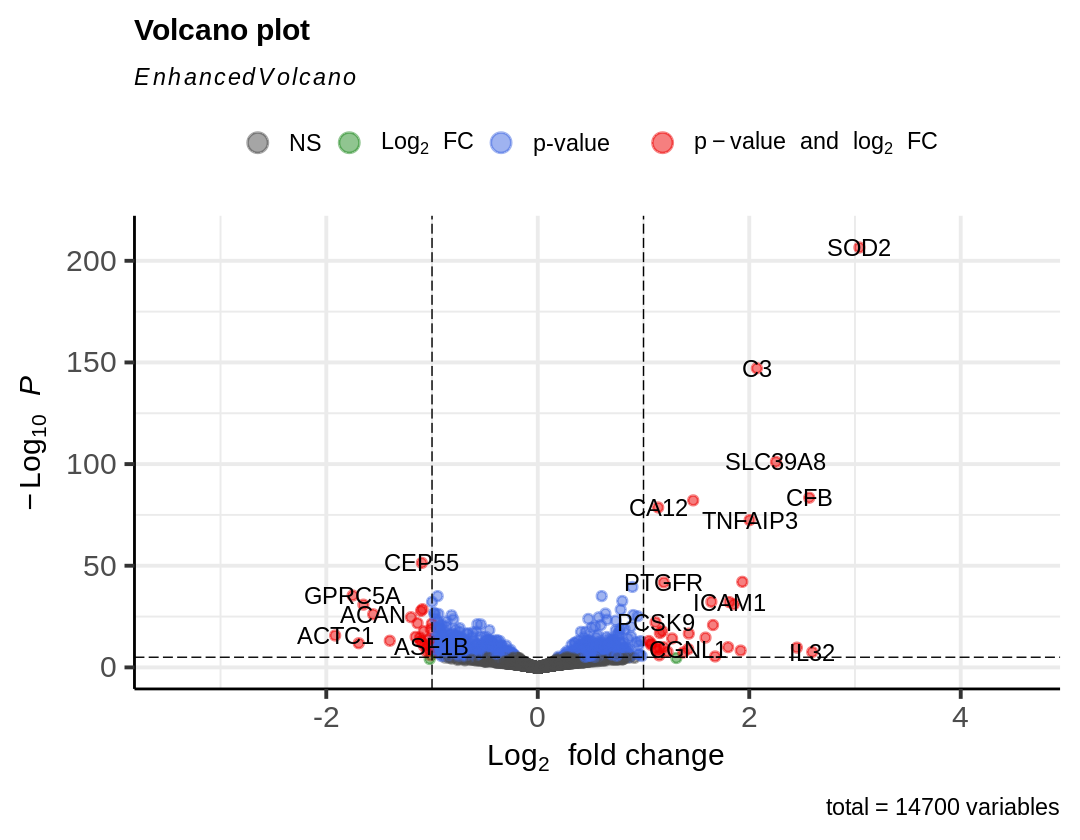

In [ ]:
res<- results(dds, contrast=list("group.cornea_CoV2", "group.cornea_mock")) # Let's obtain the results, as these contain the wald st
resLFC <- lfcShrink(dds, contrast=list("group.cornea_CoV2", "group.cornea_mock"), type="ashr")
EnhancedVolcano(resLFC,
                lab = rownames(resLFC),
                x = 'log2FoldChange',
                y = 'pvalue')

Another way is to use a a numeric contrast vector with one element for each element in ‘resultsNames(object)’ (most general case).

In [ ]:
resultsNames(dds)
resLFC_2 <- lfcShrink(dds, contrast=c(1,-1,0,0,0,0), type="ashr")
identical(resLFC$log2FoldChange, resLFC_2$log2FoldChange)

[1] "group.cornea_CoV2" "group.cornea_mock" "group.limbus_CoV2"
[4] "group.limbus_mock" "group.sclera_CoV2" "group.sclera_mock"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



[1] TRUE

We observe that the two approaches give us identical results.


### Exercises


* Using the mean group model, how can we obtain the DEG between CoV2 and mock in limbus?
* As a follow up to the previous question, can you try different ways to perform the contrast? For example, using a list or a numeric contrast vector?


## 02 GSEA and ORA

This session will guide you to perform gene set enrichment analysis (GSEA) and over representation analysis (ORA).

The objectives of this session are:

* Become familiar with the GSEA and ORA functions
* Visualize and interpret results from GSEA and ORA


### GSEA

#### Load gene sets

In [ ]:
geneset_file <- GSA::GSA.read.gmt(paste0(dir_project, "data/h.all.v2025.1.Hs.symbols.gmt"))
geneSets <- geneset_file$genesets
names(geneSets)<- geneset_file$geneset.names

12345678910111213141516171819202122232425262728293031323334353637383940414243444546474849501
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


#### Running GSEA

The core of the GSEA analysis is done by the fgsea function. To run it, we need to first obtain a vector to rank our genes.

In [ ]:
head(res)
geneRanks<- res$stat
names(geneRanks)<- rownames(res)
head(geneRanks)

log2 fold change (MLE): group.cornea_CoV2 vs group.cornea_mock 
Wald test p-value: group.cornea_CoV2 vs group.cornea_mock 
DataFrame with 6 rows and 6 columns
          baseMean log2FoldChange     lfcSE      stat      pvalue      padj
         <numeric>      <numeric> <numeric> <numeric>   <numeric> <numeric>
A1BG       90.4475     -0.3234786 0.1858483 -1.740552 0.081762169 0.2592268
A1BG-AS1  278.3007     -0.0626454 0.1219786 -0.513577 0.607547777 0.8036976
A2M       873.3212     -0.4794032 0.1900402 -2.522642 0.011647706 0.0687980
A2M-AS1    11.3404      0.5897878 0.4671506  1.262522 0.206761050 0.4497418
A4GALT    775.8491      0.4498681 0.1159353  3.880337 0.000104312 0.0015732
AAAS      741.3456     -0.1308305 0.0878288 -1.489609 0.136327113 0.3482062

A1BG  A1BG-AS1       A2M   A2M-AS1    A4GALT      AAAS 
-1.740552 -0.513577 -2.522642  1.262522  3.880337 -1.489609

For GSEA, we will use the Wald test statistics stored in the stat column from the results, which are effectively the log2FoldChange/SE.

In [ ]:
fgseaRes <- fgsea(pathways = geneSets,
                  stats    = geneRanks,
                  eps = 0, # For better p-value estimation
                  minSize  = 15,
                  maxSize  = 500)

#### Explore results

pathway,pval,padj,log2err,ES,NES,size,leadingEdge
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<list>
HALLMARK_CHOLESTEROL_HOMEOSTASIS,9.412801e-10,5.229334e-09,0.7881868,0.6521267,2.476110,69,"LSS, HMG...."
HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION,1.268355e-11,1.056963e-10,0.8753251,0.5172049,2.293238,195,"TNFAIP3,...."
HALLMARK_TNFA_SIGNALING_VIA_NFKB,5.785551e-10,3.615970e-09,0.8012156,0.5079691,2.237759,176,"SOD2, TN...."
HALLMARK_INTERFERON_GAMMA_RESPONSE,1.599030e-09,7.995149e-09,0.7881868,0.5095403,2.216424,166,"SOD2, CF...."
HALLMARK_COAGULATION,7.164234e-07,2.388078e-06,0.6594444,0.5456390,2.186081,92,"C3, CFB,...."
HALLMARK_MYOGENESIS,8.989900e-08,3.745792e-07,0.7049757,0.4900387,2.117107,151,"SVIL, ST...."


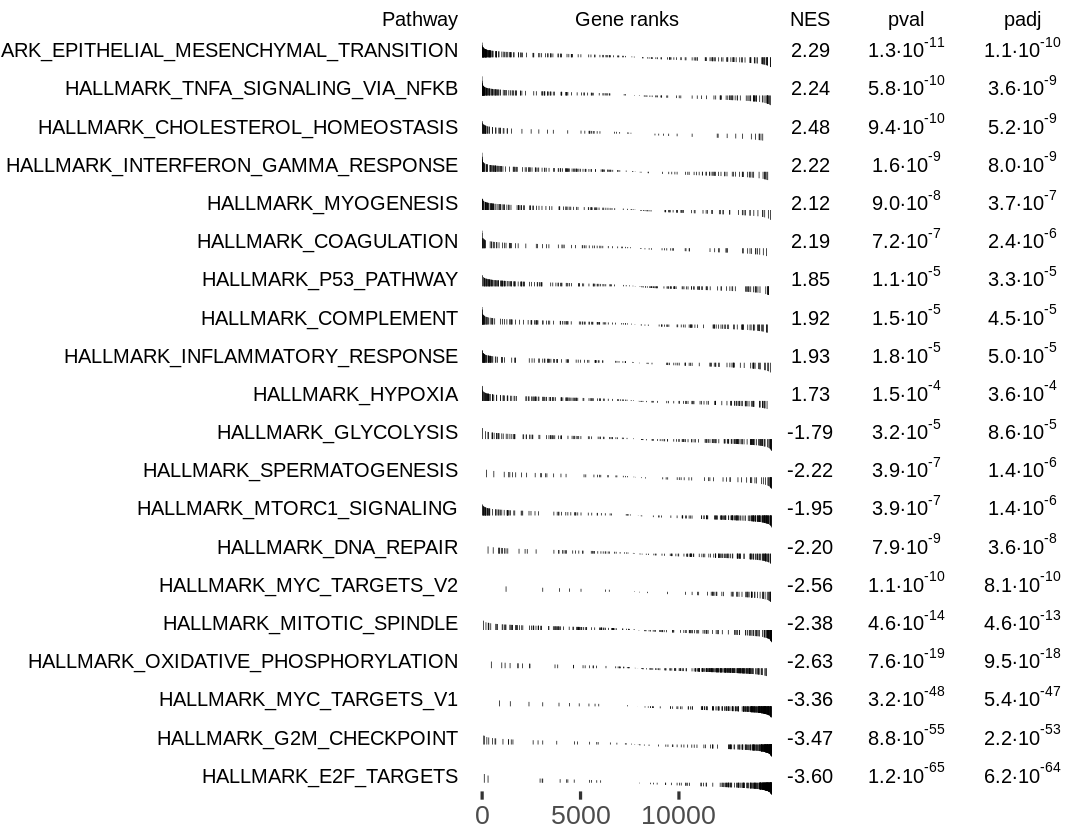

In [ ]:
head(fgseaRes[order(-NES,pval)])
topPathwaysUp <- fgseaRes[ES > 0][head(order(pval), n=10), pathway]
topPathwaysDown <- fgseaRes[ES < 0][head(order(pval), n=10), pathway]
topPathways <- c(topPathwaysUp, rev(topPathwaysDown))
plotGseaTable(geneSets[topPathways], geneRanks, fgseaRes,
              gseaParam=0.5)

We can visualize also as a simple barplot.

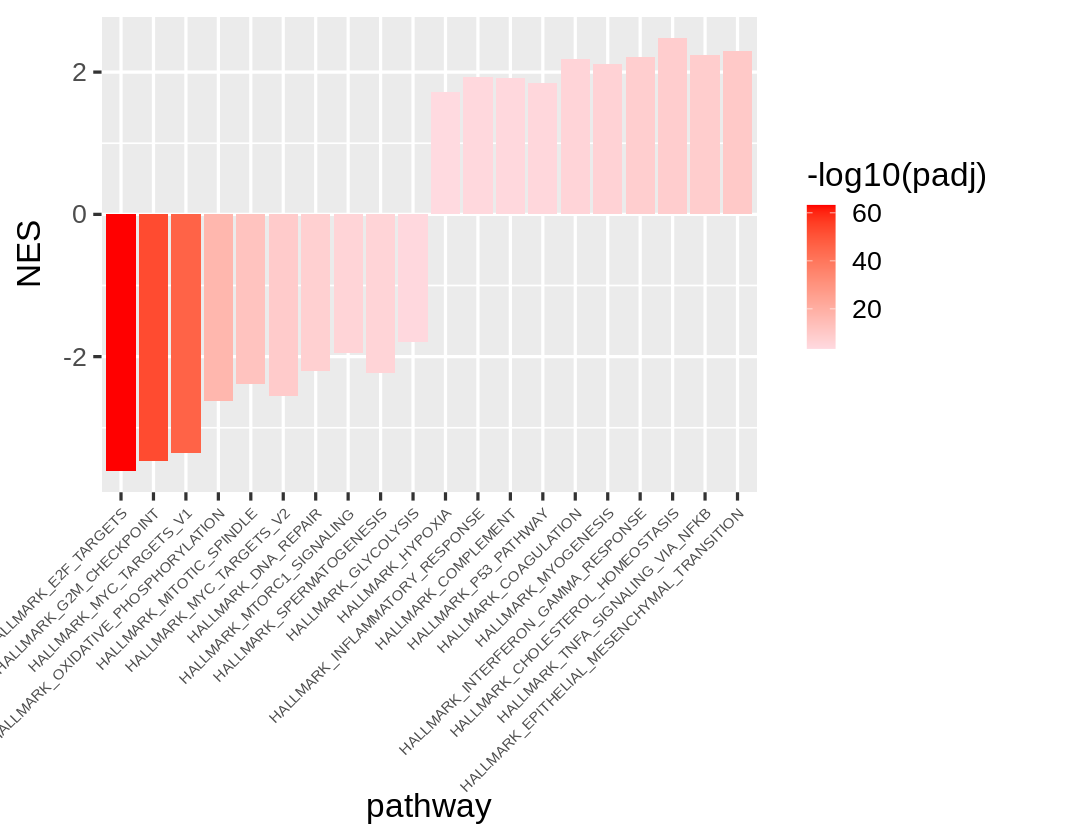

In [ ]:
df_gsea<- as.data.frame(fgseaRes)
df_gsea<- df_gsea[with(df_gsea, pathway %in% topPathways),]
df_gsea$pathway<- factor(df_gsea$pathway, levels=rev(topPathways)) # convert to factor and order the levels for plotting
ggplot(df_gsea, aes(x=pathway, y=NES, fill=-log10(padj)) )+
    geom_bar(stat="identity") +
    scale_fill_continuous(low="#ffdae0", high="red")+
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, size=9))

We observe enrichment for TNFa signaling, Interferon gamma response and EMT pathways in CoV2 condition, while proliferation pathway enrichment in the mock.

#### Enrichment plots

We can also visualize the enrichment of a specific pathway

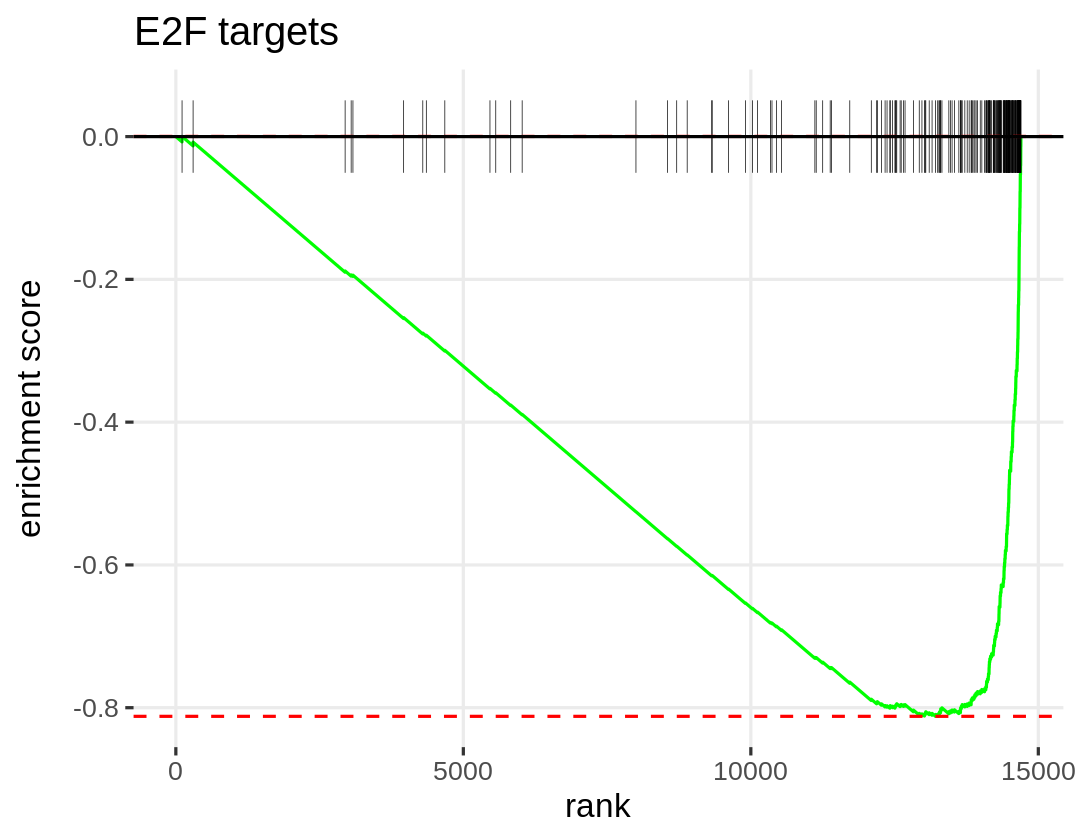

In [ ]:
plotEnrichment(geneSets[["HALLMARK_E2F_TARGETS"]],
               geneRanks) + labs(title="E2F targets")

We observe very strong enrichment for the E2F targets gene set in the mock.

#### Visualize leading edge genes

We can visualize the leading edge genes for a particular pathway, in this case, the E2F targets.

[1] "RRM2"    "CDK1"    "HMMR"    "TOP2A"   "DLGAP5"  "RACGAP1"

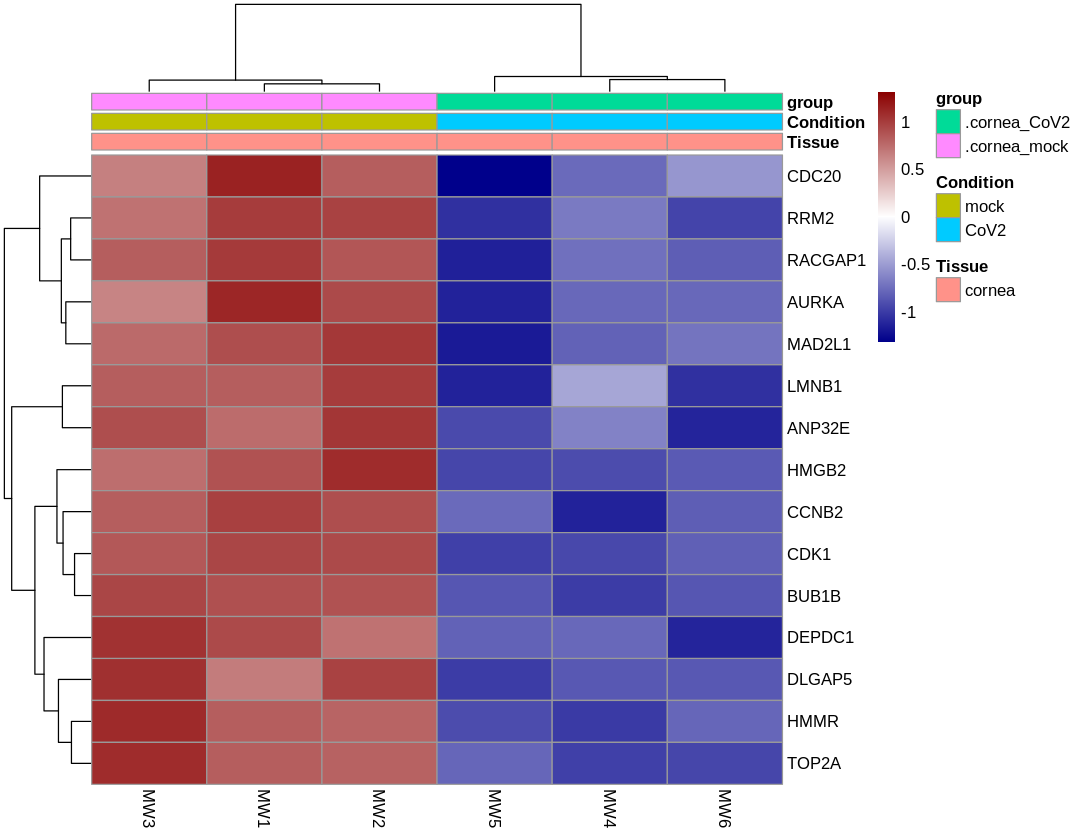

In [ ]:
leadingEdges<- unlist(df_gsea[with(df_gsea, pathway == "HALLMARK_E2F_TARGETS"),"leadingEdge"])
head(leadingEdges)
# Let's filter for only cornea samples
meta_subset<- meta[with(meta, Tissue == "cornea"),]
colors <- colorRampPalette(c("darkblue","white","darkred"))(255)
pheatmap(assay(vsd[head(leadingEdges,15),rownames(meta_subset)]), annotation_col=meta_subset,col=colors, scale="row")

### Over representation analysis

#### Running enrichR

We will be running enrichR, which requires to establish a connection to the [Enrichr](https://maayanlab.cloud/Enrichr/) website.

For running the next steps, please make sure that your connection is live:

In [ ]:
websiteLive <- getOption("enrichR.live")
websiteLive

[1] TRUE

You can check the databases available for GSEA:

In [ ]:
dbs <- listEnrichrDbs()
head(dbs)

,geneCoverage,genesPerTerm,libraryName,link,numTerms,appyter,categoryId
,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>
1,13362,275,Genome_Browser_PWMs,http://hgdownload.cse.ucsc.edu/goldenPath/hg18/database/,615,ea115789fcbf12797fd692cec6df0ab4dbc79c6a,1
2,27884,1284,TRANSFAC_and_JASPAR_PWMs,http://jaspar.genereg.net/html/DOWNLOAD/,326,7d42eb43a64a4e3b20d721fc7148f685b53b6b30,1
3,6002,77,Transcription_Factor_PPIs,,290,849f222220618e2599d925b6b51868cf1dab3763,1
4,47172,1370,ChEA_2013,http://amp.pharm.mssm.edu/lib/cheadownload.jsp,353,7ebe772afb55b63b41b79dd8d06ea0fdd9fa2630,7
5,47107,509,Drug_Perturbations_from_GEO_2014,http://www.ncbi.nlm.nih.gov/geo/,701,ad270a6876534b7cb063e004289dcd4d3164f342,7
6,21493,3713,ENCODE_TF_ChIP-seq_2014,http://genome.ucsc.edu/ENCODE/downloads.html,498,497787ebc418d308045efb63b8586f10c526af51,7


Let's do an enrichment analysis of genes upregulated in CoV2 using the Hallmark gene set.

In [ ]:
sig_genes<- rownames(res[with(res, abs(log2FoldChange > 1) & padj < 0.05 & !is.na(padj)),])
# Defining a background as the set of genes tested
background<- rownames(res)
enriched <- enrichr(genes=sig_genes, databases=c("MSigDB_Hallmark_2020"), background=background)
head(enriched[["MSigDB_Hallmark_2020"]])

Uploading data to Speedrichr...
 - Your gene set... Done.
 - Your background... Done.
Getting enrichment results...
 - MSigDB_Hallmark_2020... Done.
Parsing results... Done.


,Term,Rank,P.value,Adjusted.P.value,Old.P.value,Old.Adjusted.P.value,Odds.Ratio,Combined.Score,Genes
,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>
1,TNF-alpha Signaling via NF-kB,1,1.465945e-09,4.251240e-08,0,0,12.652793,257.36750,CXCL6;IL6;TNFAIP6;ZC3H12A;TNFAIP2;G0S2;TNFAIP3;CXCL1;MSC;SOD2;ICAM1;RELB
2,Inflammatory Response,2,2.141420e-07,3.105059e-06,0,0,12.025748,184.67491,P2RX7;CXCL6;IL6;TNFAIP6;IRAK2;ITGB8;SCARF1;CX3CL1;ICAM1
3,Complement,3,5.871669e-07,5.675947e-06,0,0,10.583672,151.85407,C3;DPP4;IL6;PCSK9;TNFAIP3;CXCL1;CFB;CTSS;C2
4,Interferon Gamma Response,4,1.359524e-06,9.856546e-06,0,0,9.508118,128.43923,IL6;SOCS1;VCAM1;TNFAIP6;TNFAIP2;TNFAIP3;SOD2;CFB;ICAM1
5,Allograft Rejection,5,8.566858e-05,4.968777e-04,0,0,9.221327,86.35795,IL6;SOCS1;IL16;CTSS;C2;ICAM1
6,Epithelial Mesenchymal Transition,6,2.678377e-04,1.294549e-03,0,0,6.100036,50.17359,IL32;CXCL6;LRRC15;IL6;VCAM1;TNFAIP3;CXCL1


We can plot a barplot of the results

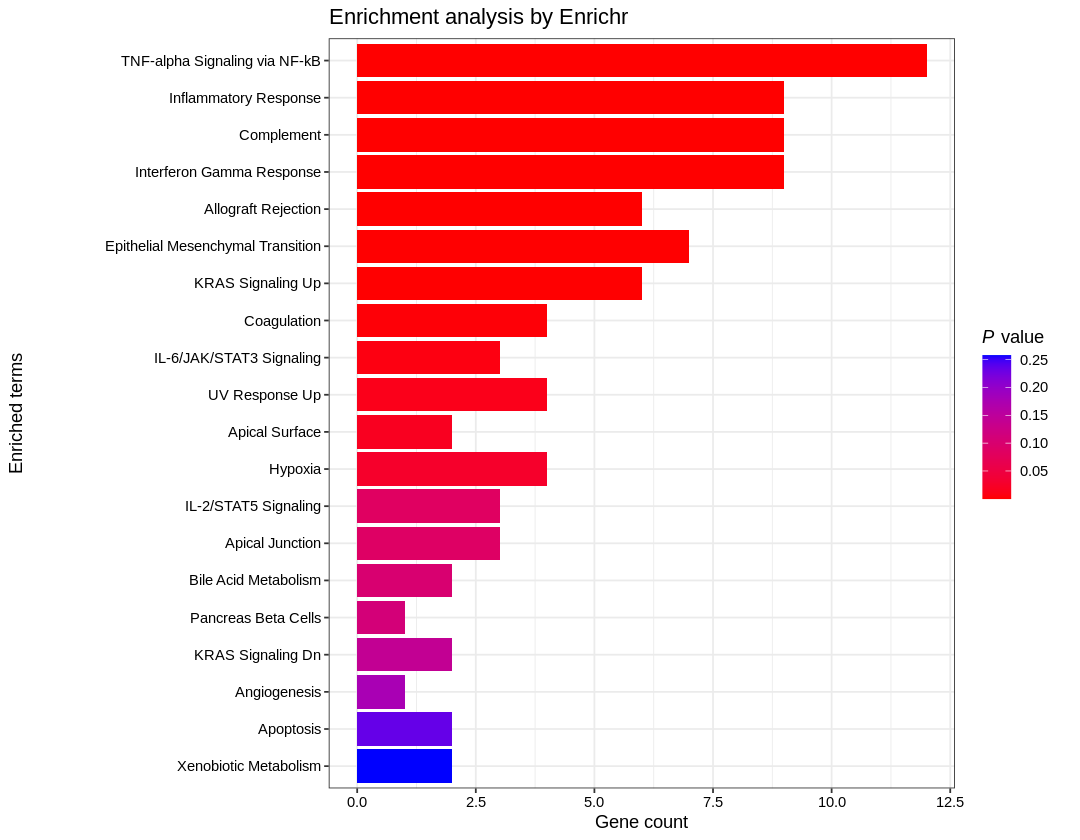

In [ ]:
plotEnrich(enriched[["MSigDB_Hallmark_2020"]],
           showTerms = 20, numChar = 40,
            y = "Count", orderBy = "P.value")

#### Exercises

* Run GSEA using a different gene set. You can find the KEGG legacy gene set in the [data](https://github.com/QLS-MiCM/Differential-Gene-Expression-Analysis/tree/main/Exercises/data) folder.


## Acknowledgements

This notebook used material adapted from the following sources:

* [DESeq2 vignette](https://www.bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)
* [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html)
* [fgsea vignette](https://bioconductor.org/packages/release/bioc/vignettes/fgsea/inst/doc/fgsea-tutorial.html)
* [enrichR vignette](https://cran.r-project.org/web/packages/enrichR/vignettes/enrichR.html)

## Session info

In [ ]:
sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] BiocManager_1.30.27         enrichR_3.4                
 [3] GSA_1.03.3                  fgsea_1.38.0               
 [5] knitr_1.51                  ashr_2.2-6